In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns  

0. Znajdź i pobierz zbiór danych IRIS z repozytorium danych UCI. Dowiedz się co opisują pobrane
dane (wskazówka: przeczytaj plik iris.names, a terminy biologiczne rozjaśnią ilustracje z
wikipedii).

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
iris = fetch_ucirepo(id=53) 
  
# data (as pandas dataframes) 
X = iris.data.features 
y = iris.data.targets 

In [3]:
# z pliku, ale tam nie ma podaych nazw kolumn
column_names = ["sepal_length", "sepal_width", "petal_length", "petal_width", "class"]
iris = pd.read_csv("iris.data", header=None, names=column_names)


5. Number of Instances: 150 (50 in each of three classes)

6. Number of Attributes: 4 numeric, predictive attributes and the class

7. Attribute Information:
   1. sepal length in cm
   2. sepal width in cm
   3. petal length in cm
   4. petal width in cm
   5. class: 
      -- Iris Setosa
      -- Iris Versicolour
      -- Iris Virginica

SEPAL to działka kielicha
PETAL to płatek

1. Jakie wartości przyjmuje sepal length? Zrób wykres (typu scatter plot): na osi X numer
próbki danych, na osi Y wartość sepal length. Czy jest sens łączyć kropki na tym wykresie?

Text(0, 0.5, 'Sepal Length (cm)')

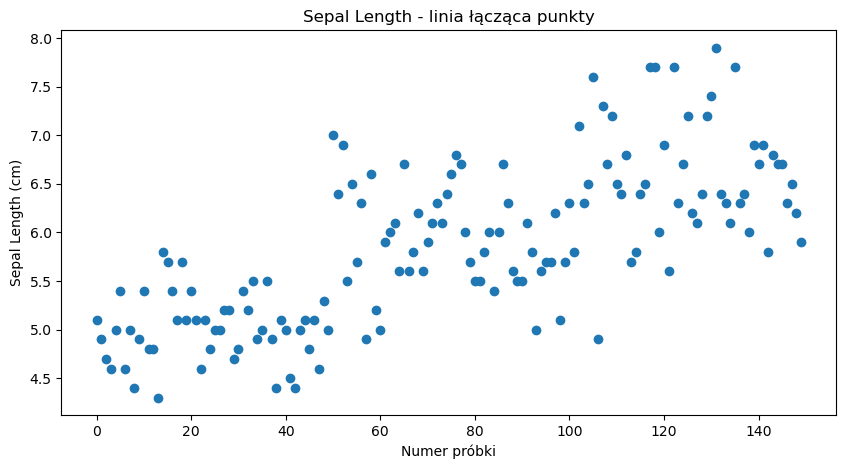

In [4]:
sepal_length = iris["sepal_length"]

plt.figure(figsize=(10, 5)) # tworzymy nowe "płutno" do rysowania o wymiarze 10x5

n = len(iris) # liczba próbek

plt.scatter(range(n), sepal_length)

# Scatter plot (wykres punktowy) pokazuje relacje między dwiema zmiennymi
# Każdy punkt na wykresie reprezentuje jedną obserwację

plt.title("Sepal Length - linia łącząca punkty")
plt.xlabel("Numer próbki")
plt.ylabel("Sepal Length (cm)")

Póki co, nie widzę tutaj niczego w czym pomogło połączenie tych punktów "kreskami". Łącznie ich miałoby jakiś sens gdybyśmy wiedzieli, że dane są uporzakowane gatunaki (tutaj akurat tak jest), ale sam arbitralny porządek danych nie powinien nam podpowiadać żadnej struktury.

Chociaż pewnie też zależy co to znaczy "łączyć kropki" :) 

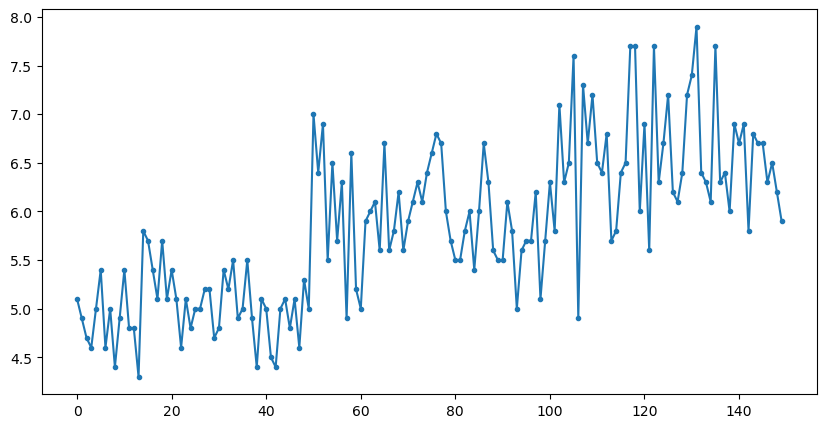

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(range(n), sepal_length, marker='.', linestyle='-') # styl kropeczek oraz lini pomiędzy 

A tutaj połączone.

2. Sprawdź ile jest próbek danych klasy iris setosa, dla których sepal width jest mniejszy niż
2.5. A między 2.5 i 3.0? A między 3.0 i 3.5? Itd. Zrób odpowiedni wykres (typu słupkowego).
Czy zrobiłeś histogram?

Liczba próbek Iris-setosa: 50


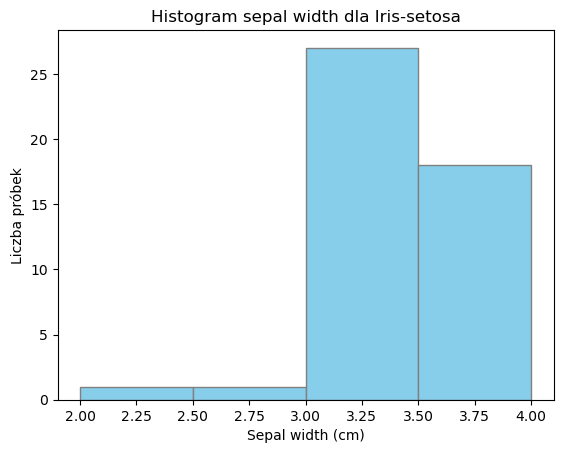

In [6]:
setosa = iris[iris["class"] == "Iris-setosa"] # wybieramy tylko próbki Iris-setosa

bins = [2.0, 2.5, 3.0, 3.5, 4.0] # to będzie reprezentować odpowiednie przedziały [(2.0, 2.5), (2.5, 3.0), (3.0, 3.5), (3.5, 4.0)]

print(f"Liczba próbek Iris-setosa: {len(setosa)}")

# Rysujemy histogram sepal width
plt.hist(setosa["sepal_width"], bins=bins, edgecolor='gray', color='skyblue') # liczy próbki dzieląc dane na podane przedziały
plt.title("Histogram sepal width dla Iris-setosa")
plt.xlabel("Sepal width (cm)")
plt.ylabel("Liczba próbek")
plt.show()

3. Zrób wykres (typu scatter plot): na osi X sepal length, na osi Y sepal width. Czy jest
sens łączyć kropki na tym wykresie? Pokoloruj kropki trzema różnymi kolorami w zależności
od gatunku irysa. Ustaw rozmiar kropek proporcjonalnie do petal length (skalę rozmiarów
dobierz tak, aby rysunek był czytelny). Co ciekawego widać na tym wykresie? Czy potrafisz
wykorzystać wykres, żeby podać regułę odróżniania iris setosa od pozostałych dwóch gatunków
irysa?

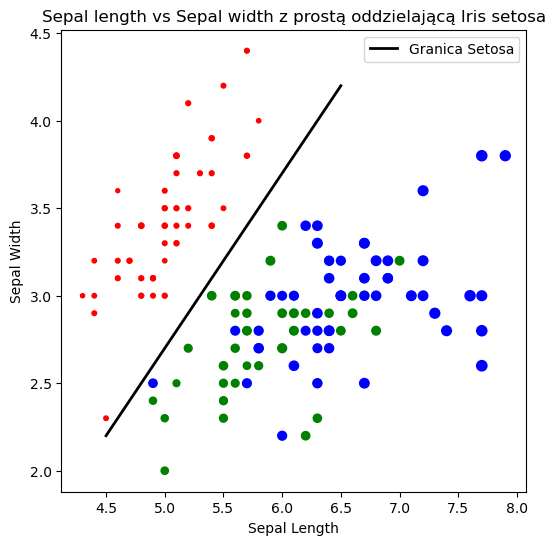

In [7]:
colors = {'Iris-setosa': 'red', 'Iris-versicolor': 'green', 'Iris-virginica': 'blue'} # mapa kolorów dla klas

plt.figure(figsize=(6, 6))
plt.scatter(iris["sepal_length"], iris["sepal_width"], color=iris["class"].map(colors), s=iris["petal_length"]*8)

x_values = np.linspace(4.5, 6.5, 100)
y_values = 2.2 + (x_values - 4.5) * 1 

# Rysujemy prostą
plt.plot(x_values, y_values, color="black", linewidth=2, label="Granica Setosa")

plt.title("Sepal length vs Sepal width z prostą oddzielającą Iris setosa")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.legend()
plt.show()

Ciekawe: 
1) czerwone (setosa) są zdala od reszty (y(x) = 2.2 + (x - 4.5) * 1 dobrze rozdziela, chociaż pewnie nie idealnie)
2) wygląda to trochę tak, że pozostałe gatunki tzn zielony i niebieski mają (raczej podobnie) liniowo skorelowaną długość i szerokość kielicha, tzn im większa długość tym większa szerokość

4. Zrób wykres z poprzedniego punktu dla każdej pary różnych atrybutów danych. Przemyśl, czy
nie będzie wygodnie ustawić wykresy w jakiś sposób obok siebie, a nie jeden pod drugim.

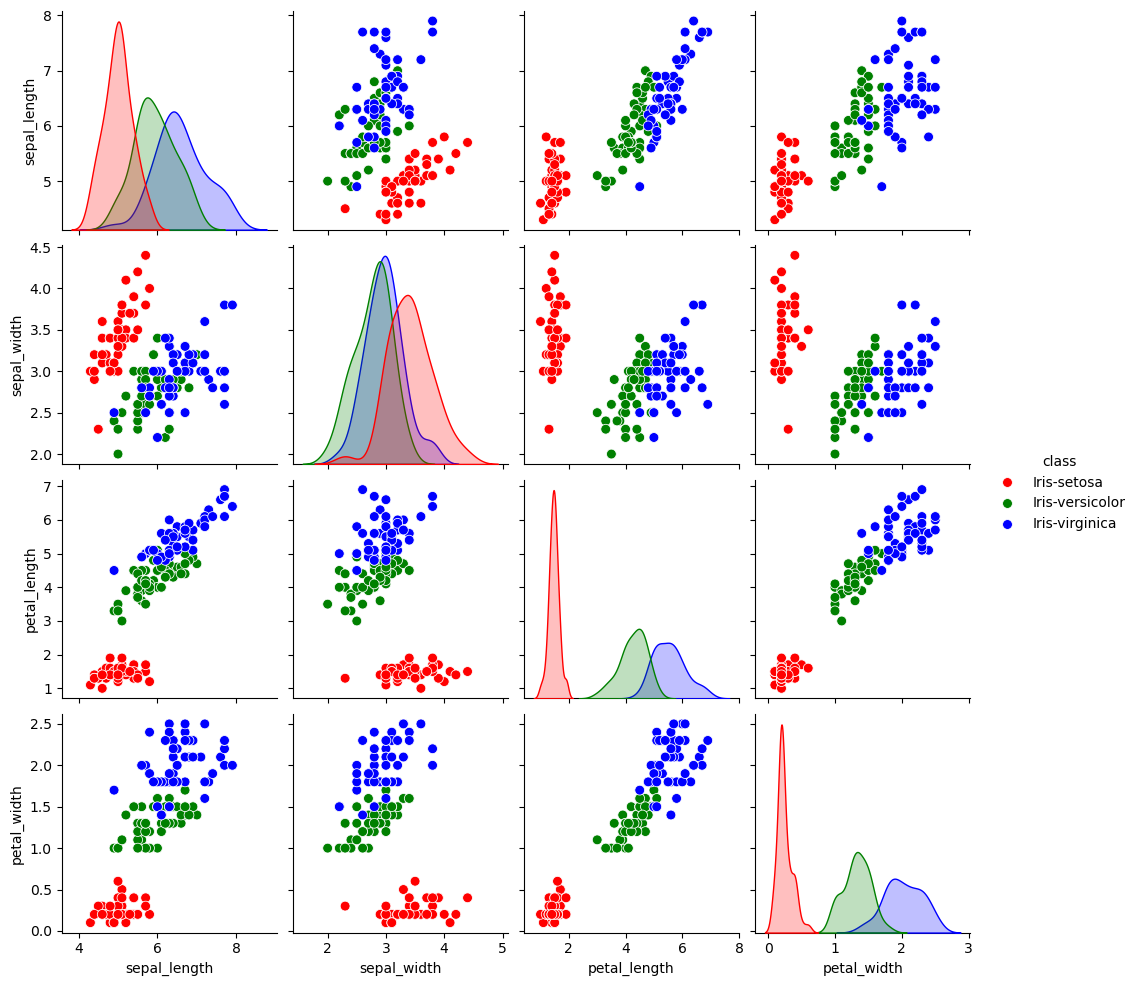

In [8]:
# Bardzo wygodne !!!
sns.pairplot(
    iris,
    vars=column_names[:-1],  # wszystkie kolumny oprócz class
    hue="class", # rozróżnia próbki według klasy
    palette=colors,
    plot_kws={"s": 50}  # sprytny sposób na ustawienie parametrów wykresu, ale tutaj nie mogłem zróbic proporcjoalnie jak wcześniej, ale widocznie
)

plt.show()


5. Dowiedz się czym jest wykres skrzypcowy (ang. violin plot) i zrób go dla atrybutów danych.

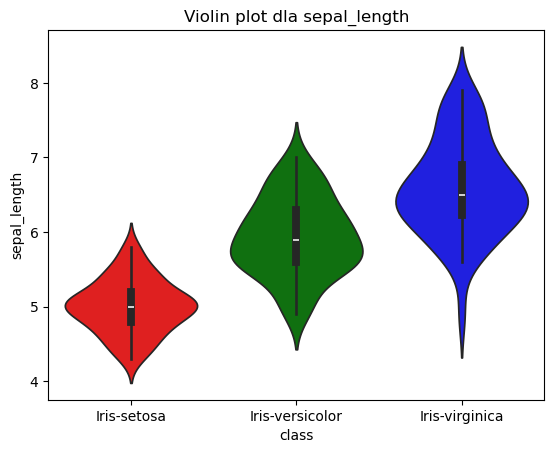

In [9]:
sns.violinplot(x="class", y="sepal_length", data=iris, hue="class",palette={"Iris-setosa":"red","Iris-versicolor":"green","Iris-virginica":"blue"})
plt.title("Violin plot dla sepal_length")
plt.show()

Kształt brzucha to po prostu apoksymacja gęstości na postawie danych. 
Biały pasek to mediana
Grubsza cześć pałki to wyznacza kwartyle (1/4) na lewo i prawo od mediany. 
Dolny wąs=Q1 − 1.5×(Q3 - Q1)
Górny wąs=Q3 + 1.5×(Q3 - Q1)